In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

save_dir = Path(r"F:\ANU_course\code_note\research_course\sight_read_2026_02_24\pykt-toolkit\examples\saved_model\yousician_deep_irt_qid_saved_model_42_0_0.2_200_0.001_50_1_1_9ff9bec4-1a65-4eb4-8668-f45bbf16e900")

stu = torch.load(save_dir / "qid_test_stu_ability.pt", map_location="cpu")
diff = torch.load(save_dir / "qid_test_que_diff.pt", map_location="cpu")

# 转 numpy（你的保存逻辑是 flatten 后的一维向量）
stu = stu.detach().cpu().numpy().reshape(-1)
diff = diff.detach().cpu().numpy().reshape(-1)

print("stu shape:", stu.shape, "diff shape:", diff.shape)
print("stu mean/std:", stu.mean(), stu.std())
print("diff mean/std:", diff.mean(), diff.std())

stu shape: (95579,) diff shape: (95579,)
stu mean/std: 0.2724295 0.3692551
diff mean/std: -0.89589757 0.09720285


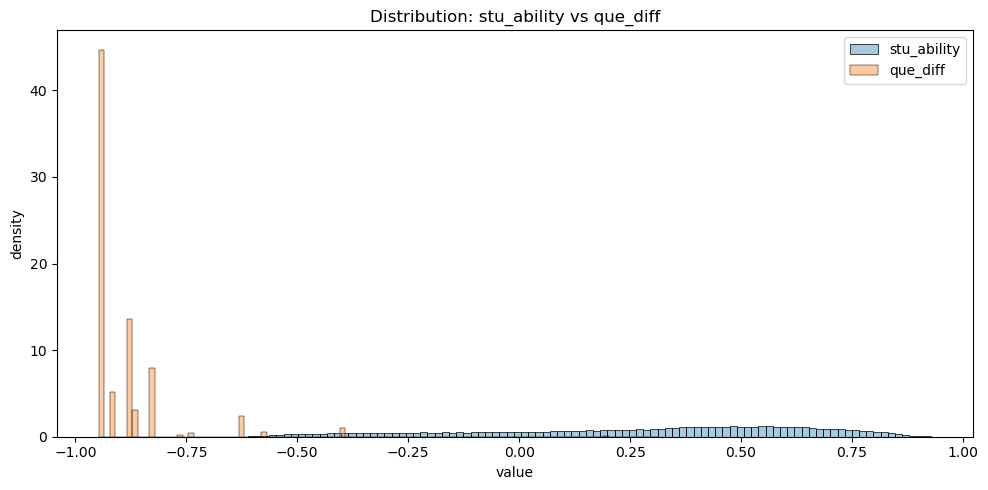

In [2]:
plt.figure(figsize=(10,5))
sns.histplot(stu, bins=100, kde=False, color="C0", stat="density", label="stu_ability", alpha=0.4)
sns.histplot(diff, bins=100, kde=False, color="C1", stat="density", label="que_diff", alpha=0.4)
plt.legend()
plt.title("Distribution: stu_ability vs que_diff")
plt.xlabel("value")
plt.ylabel("density")
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 你的保存目录

students_path = save_dir / "qid_students_last_ability.csv"
kc_rank_path = save_dir / "qid_kc_difficulty_ranking.csv"

students_df = pd.read_csv(students_path)
kc_df = pd.read_csv(kc_rank_path)

print("students_df shape:", students_df.shape)
print("kc_df shape:", kc_df.shape)
display(students_df.head())
display(kc_df.head())

students_df shape: (9, 3)
kc_df shape: (21, 5)


,uid,t,stu_ability
0,13,198,0.573719
1,16,198,0.321642
2,17,198,-0.461892
3,25,198,-0.136661
4,32,198,0.731424


,kc_id,kc_name,que_diff_mean,que_diff_median,n_obs
0,17,28,0.315155,0.315155,4
1,18,14,0.196154,0.196154,66
2,21,27,-0.082294,-0.082294,2
3,15,16,-0.089265,-0.089265,5
4,14,17,-0.165762,-0.165762,13


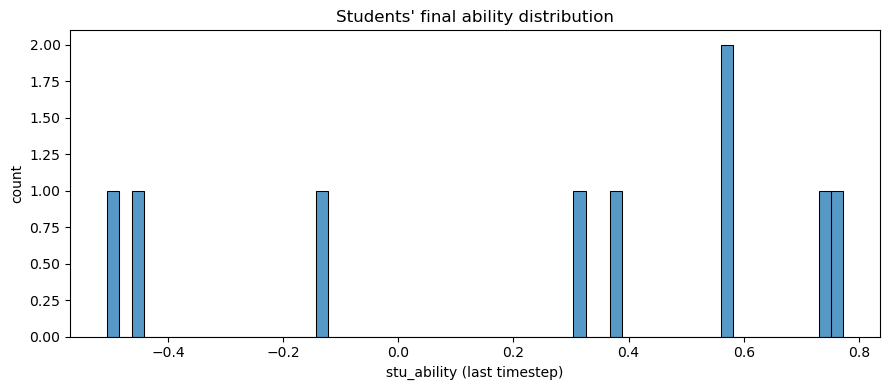

students last ability summary hello:


count    9.000000
mean     0.249527
std      0.495587
min     -0.506131
25%     -0.136661
50%      0.375069
75%      0.575682
max      0.772895
Name: stu_ability, dtype: float64

In [4]:
# 1) 所有学生最后时刻能力分布
plt.figure(figsize=(9, 4))
sns.histplot(students_df["stu_ability"], bins=60, kde=False, color="C0")
plt.title("Students' final ability distribution")
plt.xlabel("stu_ability (last timestep)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print("students last ability summary hello:")
display(students_df["stu_ability"].describe())

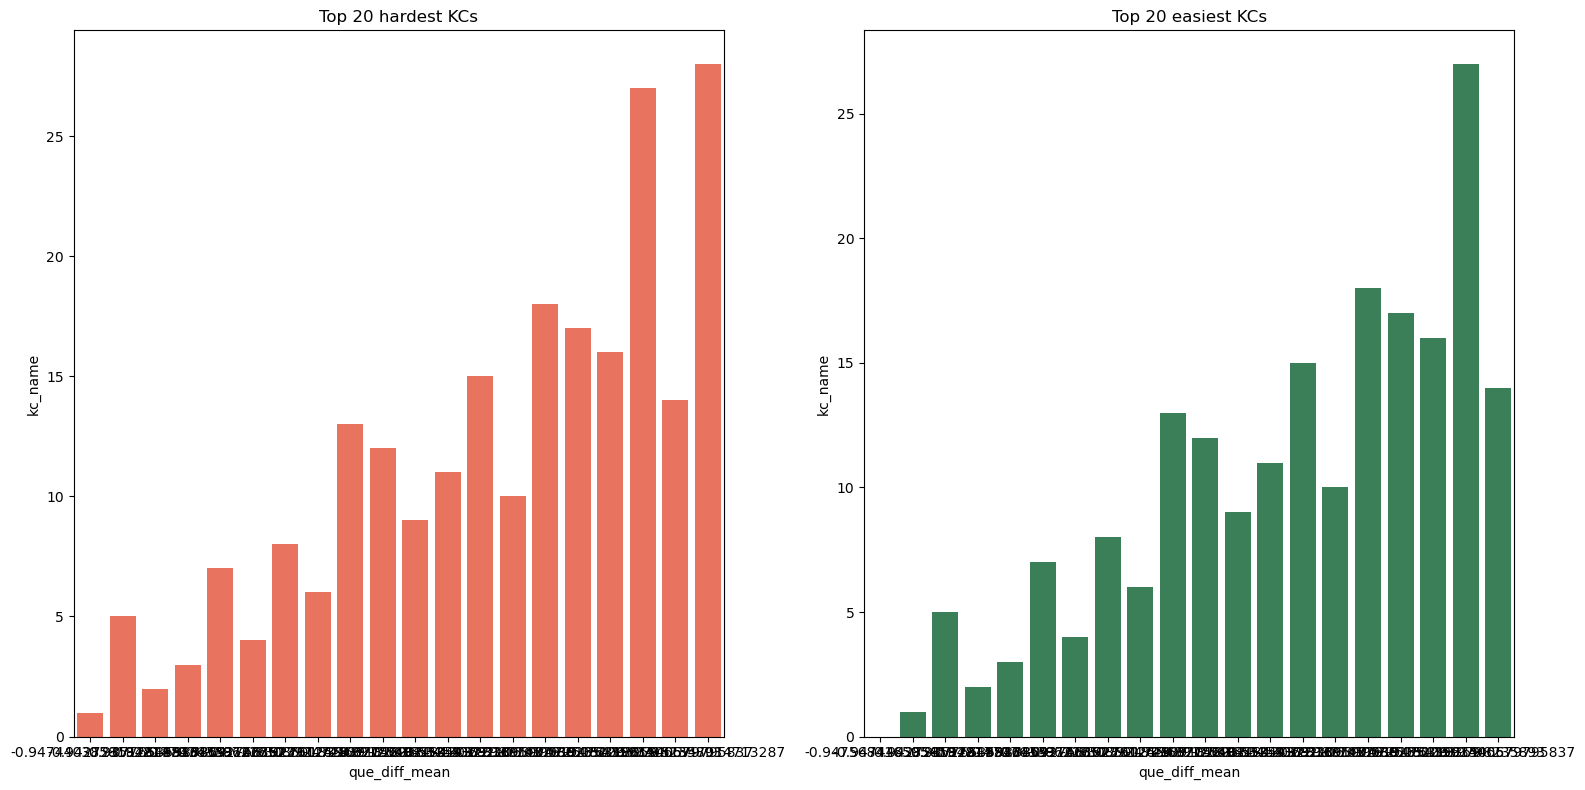

In [8]:
# 2) KC 难度 Top / Bottom（que_diff_mean 越高可理解为越难）
top_n = 20
top_hard = kc_df.head(top_n).copy()
top_easy = kc_df.tail(top_n).copy()

# 为了画图更直观，把 easy 反转一下
top_easy = top_easy.sort_values("que_diff_mean", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    data=top_hard,
    y="kc_name",
    x="que_diff_mean",
    ax=axes[0],
    color="tomato"
)
axes[0].set_title(f"Top {top_n} hardest KCs")
axes[0].set_xlabel("que_diff_mean")
axes[0].set_ylabel("kc_name")

sns.barplot(
    data=top_easy,
    y="kc_name",
    x="que_diff_mean",
    ax=axes[1],
    color="seagreen"
)
axes[1].set_title(f"Top {top_n} easiest KCs")
axes[1].set_xlabel("que_diff_mean")
axes[1].set_ylabel("kc_name")

plt.tight_layout()
plt.show()


All KCs sorted by difficulty (hard -> easy):
 kc_name  que_diff_mean
      28       0.315155
      14       0.196154
      27      -0.082294
      16      -0.089265
      17      -0.165762
      18      -0.313951
      10      -0.402821
      15      -0.553444
      11      -0.569418
       9      -0.621420
      12      -0.745072
      13      -0.761245
       6      -0.830850
       8      -0.862276
       4      -0.880928
       7      -0.884346
       3      -0.922177
       2      -0.937765
       5      -0.942724
       1      -0.947440
       0      -0.947568


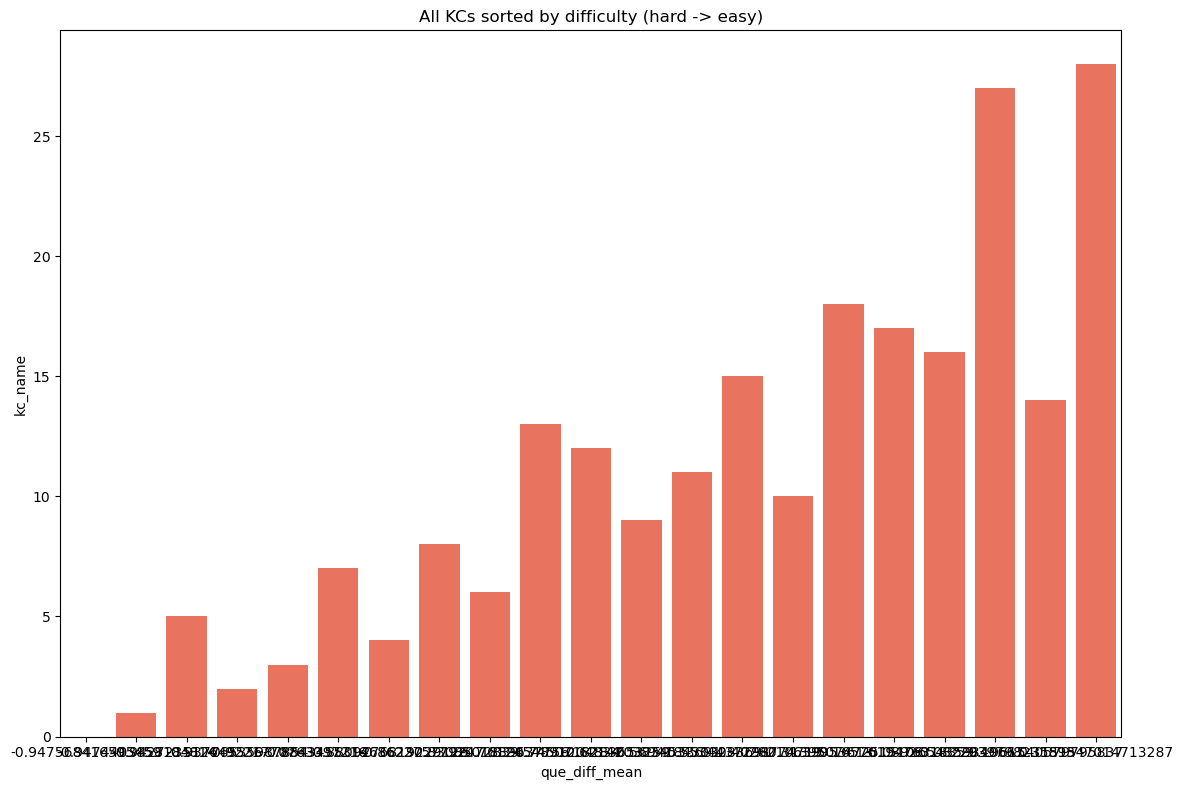

In [9]:
# 按难度从高到低排序
kc_df_sorted = kc_df.sort_values("que_diff_mean", ascending=False).copy()

print("\nAll KCs sorted by difficulty (hard -> easy):")
print(kc_df_sorted[["kc_name", "que_diff_mean"]].to_string(index=False))

# 画图
fig, ax = plt.subplots(figsize=(12, max(8, len(kc_df_sorted) * 0.3)))

sns.barplot(data=kc_df_sorted, y="kc_name", x="que_diff_mean", ax=ax, color="tomato")
ax.set_title("All KCs sorted by difficulty (hard -> easy)")
ax.set_xlabel("que_diff_mean")
ax.set_ylabel("kc_name")

plt.tight_layout()
plt.show()

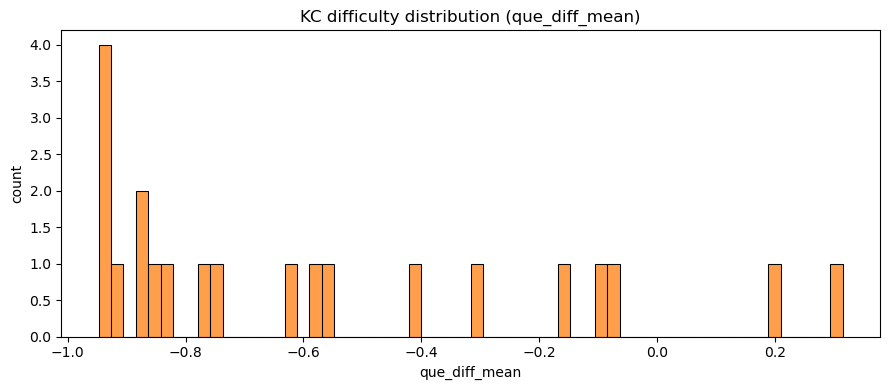

KC difficulty summary:


count    21.000000
mean     -0.569022
std       0.399917
min      -0.947568
25%      -0.884346
50%      -0.745072
75%      -0.313951
max       0.315155
Name: que_diff_mean, dtype: float64

In [6]:
# 3) KC 难度整体分布
plt.figure(figsize=(9, 4))
sns.histplot(kc_df["que_diff_mean"], bins=60, kde=False, color="C1")
plt.title("KC difficulty distribution (que_diff_mean)")
plt.xlabel("que_diff_mean")
plt.ylabel("count")
plt.tight_layout()
plt.show()

print("KC difficulty summary:")
display(kc_df["que_diff_mean"].describe())

## 直接用交互信息中的KC正确率

In [7]:
from pathlib import Path
import pandas as pd

data_txt = Path(r"F:\ANU_course\code_note\research_course\sight_read_2026_02_24\pykt-toolkit\data\yousician\data.txt")

kc_correct = {}
kc_total = {}

with open(data_txt, "r", encoding="utf-8") as f:
    lines = [ln.strip() for ln in f if ln.strip() != ""]

# 每 6 行一个样本块
for i in range(0, len(lines), 6):
    if i + 3 >= len(lines):
        break

    concepts_line = lines[i + 2]   # 第3行：concepts
    responses_line = lines[i + 3]  # 第4行：responses

    concepts = concepts_line.split(",")
    responses = responses_line.split(",")

    # 防御：长度不一致时取最短
    n = min(len(concepts), len(responses))
    for c, r in zip(concepts[:n], responses[:n]):
        # c 例如 "[60^4^3^2]"
        try:
            rv = int(float(r))
        except:
            continue
        kc_total[c] = kc_total.get(c, 0) + 1
        kc_correct[c] = kc_correct.get(c, 0) + (1 if rv == 1 else 0)

# 生成结果表
rows = []
for kc, tot in kc_total.items():
    rows.append({
        "kc_name": kc,  # 直接用 data.txt 的 KC 字符串
        "n_obs": tot,
        "correct_rate": kc_correct[kc] / tot
    })

kc_acc = pd.DataFrame(rows).sort_values("correct_rate", ascending=False).reset_index(drop=True)

display(kc_acc.head(20))   # 正确率最高
display(kc_acc.tail(20))   # 正确率最低

,kc_name,n_obs,correct_rate
0,42,4,1.000000
1,33,2,1.000000
2,36,3,1.000000
3,166,2,1.000000
4,35,1,1.000000
5,22,16,0.937500
6,2,48717,0.905864
7,1,83645,0.904609
8,0,114014,0.868235
9,3,36326,0.833425


,kc_name,n_obs,correct_rate
20,10,9841,0.760695
21,13,2830,0.759364
22,12,3506,0.744723
23,18,255,0.729412
24,27,21,0.714286
25,11,5262,0.700114
26,17,297,0.666667
27,21,44,0.659091
28,19,39,0.641026
29,24,26,0.615385
